# Neural Network Churn Classifier Using MLP

## Project Overview
This notebook implements a Multi-Layer Perceptron (MLP) neural network to predict customer churn based on transactional data. The model helps businesses identify customers at risk of churning.

**Author:** Piyush Ramteke  
**Date:** March 1, 2026  
**Model Type:** Multi-Layer Perceptron (PyTorch)

---

## 1. Import Required Libraries

Import all necessary libraries for data processing, visualization, and model building.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime

# Data preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Model evaluation
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    roc_auc_score,
    roc_curve
)

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ All libraries imported successfully")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

✓ All libraries imported successfully
PyTorch Version: 2.9.1+cpu
Device: CPU


## 2. Load and Explore Data

Load the customer transaction dataset and perform initial exploration.

In [2]:
# Load the dataset
df = pd.read_csv('Business_Analytics_Dataset_10000_Rows.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print(f"Total Features: {len(df.columns)}\n")

# Display first few rows
print("First 5 rows:")
df.head()

Dataset Shape: (10000, 13)
Total Records: 10,000
Total Features: 13

First 5 rows:


,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


In [3]:
# Dataset information
print("Dataset Information:")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("Statistical Summary:")
print("=" * 50)
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  int64  
 1   Customer_ID       10000 non-null  object 
 2   Order_Date        10000 non-null  object 
 3   Region            10000 non-null  object 
 4   Product_Category  10000 non-null  object 
 5   Customer_Segment  10000 non-null  object 
 6   Quantity          10000 non-null  int64  
 7   Unit_Price        10000 non-null  float64
 8   Discount_Rate     10000 non-null  float64
 9   Revenue           10000 non-null  float64
 10  Cost              10000 non-null  float64
 11  Profit            10000 non-null  float64
 12  Payment_Method    10000 non-null  object 
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB

Statistical Summary:


,Order_ID,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,5.51430,255.505222,0.150272,1195.241948,776.292180,418.949768
std,2886.89568,2.86451,140.832874,0.086818,979.590244,651.473171,368.418447
min,1.00000,1.00000,10.000000,0.000000,8.590000,5.740000,1.970000
25%,2500.75000,3.00000,132.777500,0.080000,396.300000,255.592500,131.785000
50%,5000.50000,5.00000,254.995000,0.150000,924.365000,595.480000,311.395000
75%,7500.25000,8.00000,377.892500,0.230000,1775.840000,1141.332500,606.845000
max,10000.00000,10.00000,499.940000,0.300000,4972.100000,3911.520000,2292.420000


In [4]:
# Check for missing values
print("Missing Values:")
print("=" * 50)
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✓ No missing values found in the dataset")
else:
    print(missing_values[missing_values > 0])
    print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values:
✓ No missing values found in the dataset


## 3. Feature Engineering - Create Churn Label

Since the dataset contains transactional data, we need to engineer a churn label. A customer is considered churned if:
- They haven't made a purchase in the last 90 days
- Or their purchase frequency is declining

In [5]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Find the latest date in dataset
latest_date = df['Order_Date'].max()
print(f"Latest transaction date: {latest_date.strftime('%Y-%m-%d')}")

# Aggregate customer-level features
customer_features = df.groupby('Customer_ID').agg({
    'Order_ID': 'count',  # Total orders
    'Order_Date': ['min', 'max'],  # First and last purchase
    'Revenue': ['sum', 'mean', 'std'],  # Revenue metrics
    'Profit': ['sum', 'mean'],  # Profit metrics
    'Discount_Rate': 'mean',  # Average discount
    'Quantity': ['sum', 'mean']  # Quantity metrics
}).reset_index()

# Flatten column names
customer_features.columns = [
    'Customer_ID', 'total_orders', 'first_purchase', 'last_purchase',
    'total_revenue', 'avg_revenue', 'std_revenue', 'total_profit',
    'avg_profit', 'avg_discount', 'total_quantity', 'avg_quantity'
]

# Calculate days since last purchase
customer_features['days_since_last_purchase'] = (
    latest_date - customer_features['last_purchase']
).dt.days

# Calculate customer lifetime (days)
customer_features['customer_lifetime_days'] = (
    customer_features['last_purchase'] - customer_features['first_purchase']
).dt.days

# Calculate purchase frequency (orders per day)
customer_features['purchase_frequency'] = (
    customer_features['total_orders'] / 
    (customer_features['customer_lifetime_days'] + 1)
)

# Handle std_revenue NaN (customers with only one order)
customer_features['std_revenue'] = customer_features['std_revenue'].fillna(0)

print(f"\n✓ Aggregated features for {len(customer_features):,} unique customers")
customer_features.head()

Latest transaction date: 2024-12-31

✓ Aggregated features for 5,994 unique customers


,Customer_ID,total_orders,first_purchase,last_purchase,total_revenue,avg_revenue,std_revenue,total_profit,avg_profit,avg_discount,total_quantity,avg_quantity,days_since_last_purchase,customer_lifetime_days,purchase_frequency
0,CUST1000,2,2024-11-15,2024-12-25,739.18,369.59,205.598368,227.89,113.945,0.085,13,6.5,6,40,0.048780
1,CUST1003,2,2024-04-24,2024-08-07,3215.94,1607.97,1250.348637,1366.27,683.135,0.060,13,6.5,146,105,0.018868
2,CUST1004,1,2024-11-03,2024-11-03,3279.23,3279.23,0.000000,971.66,971.660,0.160,9,9.0,58,0,1.000000
3,CUST1005,1,2024-05-20,2024-05-20,83.51,83.51,0.000000,17.89,17.890,0.200,1,1.0,225,0,1.000000
4,CUST1006,1,2024-02-05,2024-02-05,885.71,885.71,0.000000,288.34,288.340,0.010,6,6.0,330,0,1.000000


Churn Rate: 66.07%
Churned Customers: 3,960
Active Customers: 2,034


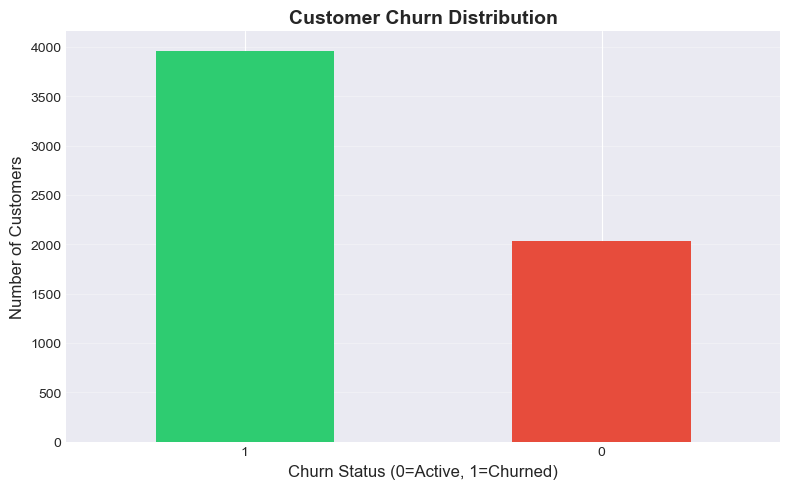

In [6]:
# Define churn based on business rules
# A customer is churned if:
# 1. No purchase in last 90 days (inactive)
# 2. OR total profit is in bottom 25% and low purchase frequency

profit_25th_percentile = customer_features['total_profit'].quantile(0.25)
freq_25th_percentile = customer_features['purchase_frequency'].quantile(0.25)

customer_features['Churn'] = (
    (customer_features['days_since_last_purchase'] > 90) |
    ((customer_features['total_profit'] <= profit_25th_percentile) & 
     (customer_features['purchase_frequency'] <= freq_25th_percentile))
).astype(int)

# Churn statistics
churn_rate = customer_features['Churn'].mean() * 100
churned_count = customer_features['Churn'].sum()
active_count = len(customer_features) - churned_count

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Churned Customers: {churned_count:,}")
print(f"Active Customers: {active_count:,}")

# Visualize churn distribution
plt.figure(figsize=(8, 5))
customer_features['Churn'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=Active, 1=Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Add Categorical Features

Include categorical features from the original dataset for richer customer profiles.

In [7]:
# Get most common category for each customer
customer_categories = df.groupby('Customer_ID').agg({
    'Region': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Product_Category': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Customer_Segment': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Payment_Method': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
}).reset_index()

# Merge with customer_features
customer_features = customer_features.merge(customer_categories, on='Customer_ID', how='left')

print("✓ Categorical features added")
print(f"Final dataset shape: {customer_features.shape}")
customer_features.head()

✓ Categorical features added
Final dataset shape: (5994, 20)


,Customer_ID,total_orders,first_purchase,last_purchase,total_revenue,avg_revenue,std_revenue,total_profit,avg_profit,avg_discount,total_quantity,avg_quantity,days_since_last_purchase,customer_lifetime_days,purchase_frequency,Churn,Region,Product_Category,Customer_Segment,Payment_Method
0,CUST1000,2,2024-11-15,2024-12-25,739.18,369.59,205.598368,227.89,113.945,0.085,13,6.5,6,40,0.048780,0,West,Clothing,Corporate,Cash on Delivery
1,CUST1003,2,2024-04-24,2024-08-07,3215.94,1607.97,1250.348637,1366.27,683.135,0.060,13,6.5,146,105,0.018868,1,East,Beauty,Home Office,Cash on Delivery
2,CUST1004,1,2024-11-03,2024-11-03,3279.23,3279.23,0.000000,971.66,971.660,0.160,9,9.0,58,0,1.000000,0,North,Beauty,Consumer,Credit Card
3,CUST1005,1,2024-05-20,2024-05-20,83.51,83.51,0.000000,17.89,17.890,0.200,1,1.0,225,0,1.000000,1,North,Beauty,Consumer,Credit Card
4,CUST1006,1,2024-02-05,2024-02-05,885.71,885.71,0.000000,288.34,288.340,0.010,6,6.0,330,0,1.000000,1,South,Beauty,Home Office,Credit Card


## 5. Data Preprocessing

### 5.1 Handle Missing Values

In [8]:
# Check for missing values in the customer features
print("Missing values in customer features:")
missing = customer_features.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])
    # Fill missing values if any
    for col in customer_features.columns:
        if customer_features[col].isnull().sum() > 0:
            if customer_features[col].dtype == 'object':
                customer_features[col].fillna(customer_features[col].mode()[0], inplace=True)
            else:
                customer_features[col].fillna(customer_features[col].median(), inplace=True)
    print("✓ Missing values handled")

Missing values in customer features:
✓ No missing values found


### 5.2 Encode Categorical Variables

In [9]:
# Identify categorical columns
categorical_cols = ['Region', 'Product_Category', 'Customer_Segment', 'Payment_Method']

print("Encoding categorical variables...")
print("=" * 50)

# Create label encoders for each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    customer_features[col] = le.fit_transform(customer_features[col])
    label_encoders[col] = le
    print(f"✓ Encoded {col}: {len(le.classes_)} unique values")

print("\n✓ All categorical variables encoded")

Encoding categorical variables...
✓ Encoded Region: 4 unique values
✓ Encoded Product_Category: 5 unique values
✓ Encoded Customer_Segment: 3 unique values
✓ Encoded Payment_Method: 5 unique values

✓ All categorical variables encoded


### 5.3 Prepare Features and Target

In [10]:
# Select features for modeling
# Drop Customer_ID, first_purchase, last_purchase (not needed for prediction)
features_to_drop = ['Customer_ID', 'first_purchase', 'last_purchase', 'Churn']
feature_columns = [col for col in customer_features.columns if col not in features_to_drop]

# Prepare X (features) and y (target)
X = customer_features[feature_columns].values
y = customer_features['Churn'].values

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")
print(f"\nNumber of Features: {len(feature_columns)}")
print("\nFeature Names:")
for i, feature in enumerate(feature_columns, 1):
    print(f"  {i}. {feature}")

Feature Matrix Shape: (5994, 16)
Target Vector Shape: (5994,)

Number of Features: 16

Feature Names:
  1. total_orders
  2. total_revenue
  3. avg_revenue
  4. std_revenue
  5. total_profit
  6. avg_profit
  7. avg_discount
  8. total_quantity
  9. avg_quantity
  10. days_since_last_purchase
  11. customer_lifetime_days
  12. purchase_frequency
  13. Region
  14. Product_Category
  15. Customer_Segment
  16. Payment_Method


## 6. Train-Test Split

Split the data into training and testing sets (80-20 split).

In [11]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

print("Data Split Summary:")
print("=" * 50)
print(f"Training Set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test Set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining Set Churn Rate: {y_train.mean()*100:.2f}%")
print(f"Test Set Churn Rate:     {y_test.mean()*100:.2f}%")

Data Split Summary:
Training Set:   4,795 samples (80.0%)
Test Set:       1,199 samples (20.0%)

Training Set Churn Rate: 66.07%
Test Set Churn Rate:     66.06%


### 6.1 Feature Scaling

Standardize features to have mean=0 and std=1 for better neural network performance.

In [12]:
# Initialize and fit the scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"\nScaled Training Set Shape: {X_train_scaled.shape}")
print(f"Scaled Test Set Shape: {X_test_scaled.shape}")
print(f"\nScaled features - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

✓ Features scaled using StandardScaler

Scaled Training Set Shape: (4795, 16)
Scaled Test Set Shape: (1199, 16)

Scaled features - Mean: 0.0000, Std: 1.0000


## 7. Build MLP Neural Network Model

Create a Multi-Layer Perceptron with:
- Input Layer (16 features)
- Hidden Layer 1 (128 neurons, ReLU, Dropout)
- Hidden Layer 2 (64 neurons, ReLU, Dropout)
- Hidden Layer 3 (32 neurons, ReLU, Dropout)
- Output Layer (1 neuron, Sigmoid)

In [13]:
class MLPClassifier(nn.Module):
    """
    Multi-Layer Perceptron for Binary Classification
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        """
        Initialize the MLP
        
        Args:
            input_dim (int): Number of input features
            hidden_dims (list): List of hidden layer dimensions
            dropout_rate (float): Dropout probability for regularization
        """
        super(MLPClassifier, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.dropout_rate = dropout_rate
        
        # Build network layers
        layers = []
        
        # Input to first hidden layer
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        
        # Hidden layers
        for i in range(len(hidden_dims) - 1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
        
        # Output layer
        layers.append(nn.Linear(hidden_dims[-1], 1))
        layers.append(nn.Sigmoid())
        
        # Combine all layers
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """Forward pass through the network"""
        return self.network(x)
    
    def get_architecture_summary(self):
        """Return a summary of the model architecture"""
        return {
            'input_dim': self.input_dim,
            'hidden_layers': self.hidden_dims,
            'dropout_rate': self.dropout_rate,
            'total_params': sum(p.numel() for p in self.parameters()),
            'trainable_params': sum(p.numel() for p in self.parameters() if p.requires_grad)
        }

print("✓ MLPClassifier class defined")

✓ MLPClassifier class defined


In [14]:
# Initialize the model
input_dim = X_train_scaled.shape[1]
model = MLPClassifier(
    input_dim=input_dim,
    hidden_dims=[128, 64, 32],
    dropout_rate=0.3
)

# Display model architecture
print("Model Architecture:")
print("=" * 50)
print(model)
print("\n" + "=" * 50)
print("Model Summary:")
print("=" * 50)
summary = model.get_architecture_summary()
for key, value in summary.items():
    print(f"{key:.<30} {value}")
print("=" * 50)

Model Architecture:
MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Model Summary:
input_dim..................... 16
hidden_layers................. [128, 64, 32]
dropout_rate.................. 0.3
total_params.................. 12545
trainable_params.............. 12545


## 8. Prepare Data Loaders

Convert data to PyTorch tensors and create data loaders for batch processing.

In [15]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("✓ Data loaders created")
print(f"\nBatch Size: {batch_size}")
print(f"Training Batches: {len(train_loader)}")
print(f"Test Batches: {len(test_loader)}")

✓ Data loaders created

Batch Size: 32
Training Batches: 150
Test Batches: 38


## 9. Define Training Configuration

Set up loss function, optimizer, and training parameters.

In [16]:
# Training configuration
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
num_epochs = 50

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Training Configuration:")
print("=" * 50)
print(f"Loss Function:      Binary Cross-Entropy")
print(f"Optimizer:          Adam")
print(f"Learning Rate:      0.001")
print(f"Weight Decay:       1e-5")
print(f"Epochs:             {num_epochs}")
print(f"Batch Size:         {batch_size}")
print(f"Device:             {device}")
print("=" * 50)

Training Configuration:
Loss Function:      Binary Cross-Entropy
Optimizer:          Adam
Learning Rate:      0.001
Weight Decay:       1e-5
Epochs:             50
Batch Size:         32
Device:             cpu


## 10. Train the Model

Train the MLP classifier and track training/validation metrics.

In [17]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("Starting training...\n")

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item() * X_batch.size(0)
        predictions = (outputs >= 0.5).float()
        train_correct += (predictions == y_batch).sum().item()
        train_total += y_batch.size(0)
    
    # Calculate training metrics
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item() * X_batch.size(0)
            predictions = (outputs >= 0.5).float()
            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    # Calculate validation metrics
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("\n✓ Training completed!")

Starting training...

Epoch [5/50] - Train Loss: 0.1080, Train Acc: 0.9570 | Val Loss: 0.0757, Val Acc: 0.9716
Epoch [10/50] - Train Loss: 0.0798, Train Acc: 0.9679 | Val Loss: 0.0634, Val Acc: 0.9716
Epoch [15/50] - Train Loss: 0.0684, Train Acc: 0.9735 | Val Loss: 0.0543, Val Acc: 0.9775
Epoch [20/50] - Train Loss: 0.0612, Train Acc: 0.9739 | Val Loss: 0.0451, Val Acc: 0.9791
Epoch [25/50] - Train Loss: 0.0479, Train Acc: 0.9781 | Val Loss: 0.0370, Val Acc: 0.9842
Epoch [30/50] - Train Loss: 0.0428, Train Acc: 0.9823 | Val Loss: 0.0366, Val Acc: 0.9833
Epoch [35/50] - Train Loss: 0.0385, Train Acc: 0.9837 | Val Loss: 0.0295, Val Acc: 0.9883
Epoch [40/50] - Train Loss: 0.0326, Train Acc: 0.9871 | Val Loss: 0.0358, Val Acc: 0.9858
Epoch [45/50] - Train Loss: 0.0318, Train Acc: 0.9877 | Val Loss: 0.0322, Val Acc: 0.9867
Epoch [50/50] - Train Loss: 0.0231, Train Acc: 0.9925 | Val Loss: 0.0319, Val Acc: 0.9900

✓ Training completed!


## 11. Visualize Training History

Plot training and validation metrics over epochs.

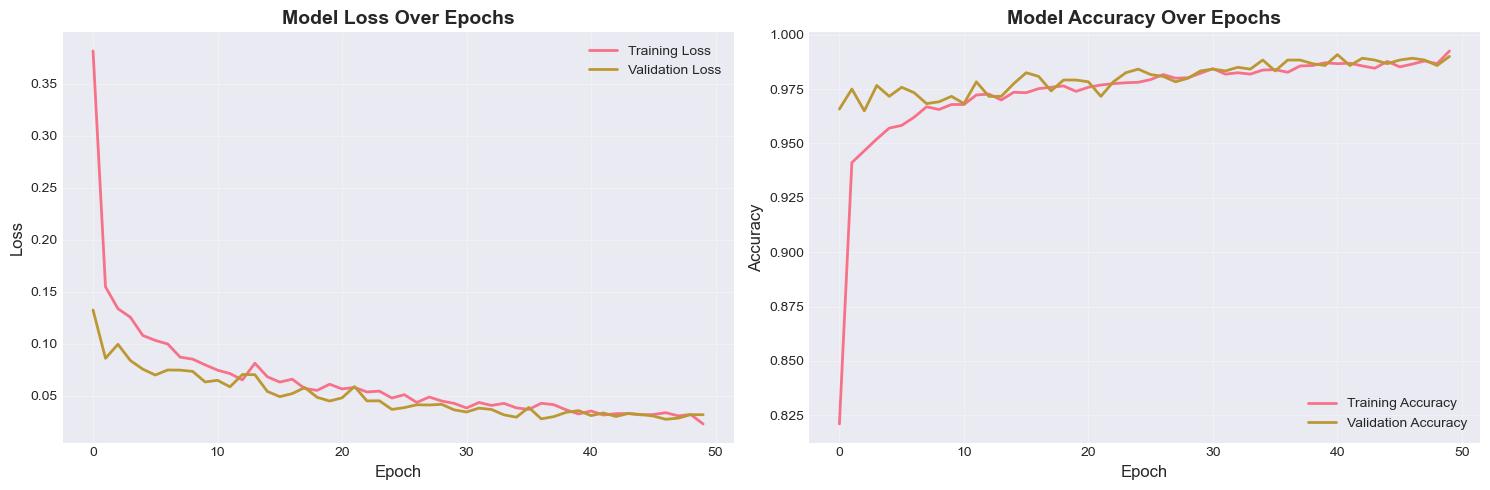


Final Training Metrics:
Training Loss:      0.0231
Training Accuracy:  0.9925
Validation Loss:    0.0319
Validation Accuracy: 0.9900


In [18]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print("=" * 50)
print(f"Training Loss:      {history['train_loss'][-1]:.4f}")
print(f"Training Accuracy:  {history['train_acc'][-1]:.4f}")
print(f"Validation Loss:    {history['val_loss'][-1]:.4f}")
print(f"Validation Accuracy: {history['val_acc'][-1]:.4f}")

## 12. Model Evaluation

### 12.1 Make Predictions

In [19]:
# Make predictions on test set
model.eval()
y_pred_probs = []
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        
        y_pred_probs.extend(outputs.cpu().numpy())
        predictions = (outputs >= 0.5).float()
        y_pred.extend(predictions.cpu().numpy())
        y_true.extend(y_batch.numpy())

# Convert to numpy arrays
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = np.array(y_pred).flatten().astype(int)
y_true = np.array(y_true).flatten().astype(int)

print("✓ Predictions generated")
print(f"\nPredictions: {len(y_pred):,}")
print(f"Predicted Churned: {y_pred.sum():,}")
print(f"Predicted Active: {(1-y_pred).sum():,}")

✓ Predictions generated

Predictions: 1,199
Predicted Churned: 790
Predicted Active: 409


### 12.2 Calculate Evaluation Metrics

In [20]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_probs)

# Print metrics
print("Model Performance Metrics:")
print("=" * 50)
print(f"Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")
print("=" * 50)

Model Performance Metrics:
Accuracy:   0.9900 (99.00%)
Precision:  0.9937
Recall:     0.9912
F1-Score:   0.9924
ROC-AUC:    0.9994


### 12.3 Confusion Matrix

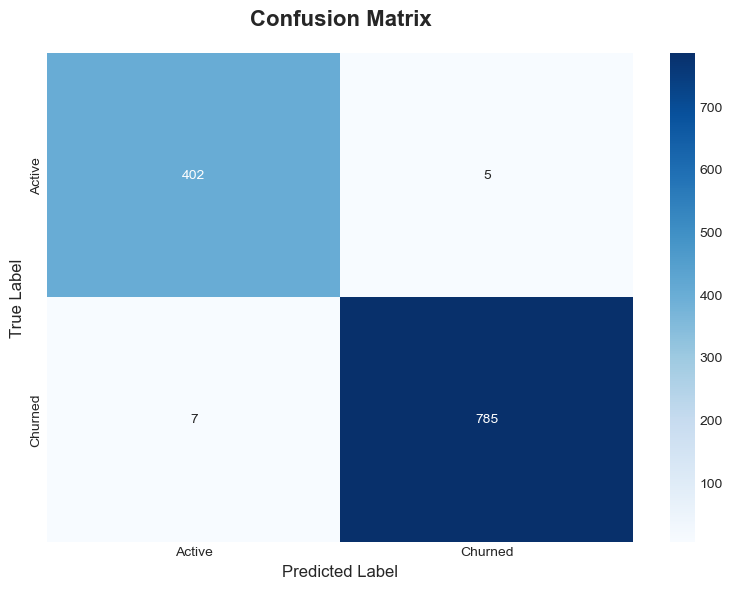


Confusion Matrix Breakdown:
True Negatives (TN):  402 - Correctly predicted Active
False Positives (FP): 5 - Incorrectly predicted Churned
False Negatives (FN): 7 - Incorrectly predicted Active
True Positives (TP):  785 - Correctly predicted Churned


In [21]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print("=" * 50)
print(f"True Negatives (TN):  {tn:,} - Correctly predicted Active")
print(f"False Positives (FP): {fp:,} - Incorrectly predicted Churned")
print(f"False Negatives (FN): {fn:,} - Incorrectly predicted Active")
print(f"True Positives (TP):  {tp:,} - Correctly predicted Churned")

### 12.4 Classification Report

In [22]:
# Generate classification report
print("Classification Report:")
print("=" * 50)
print(classification_report(y_true, y_pred, 
                          target_names=['Active', 'Churned'],
                          digits=4))

Classification Report:
              precision    recall  f1-score   support

      Active     0.9829    0.9877    0.9853       407
     Churned     0.9937    0.9912    0.9924       792

    accuracy                         0.9900      1199
   macro avg     0.9883    0.9894    0.9889      1199
weighted avg     0.9900    0.9900    0.9900      1199



### 12.5 ROC Curve

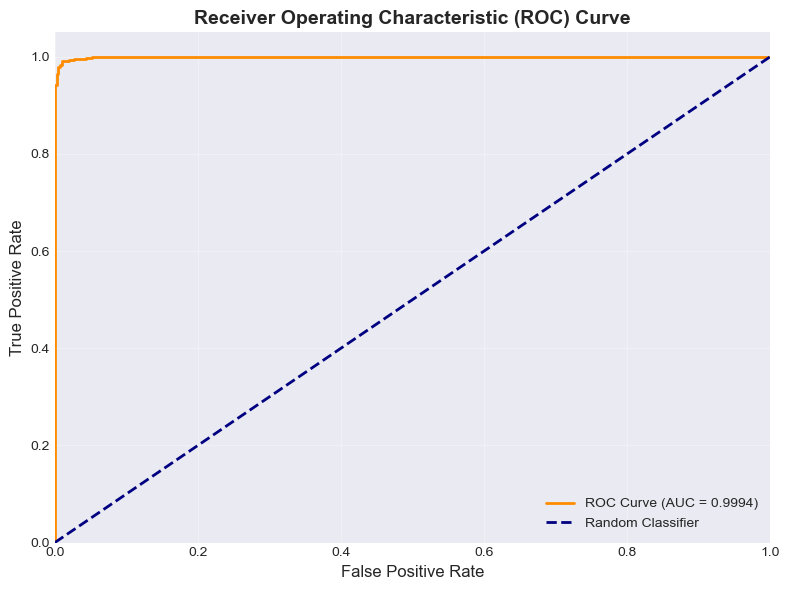

In [23]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', 
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Save the Model

Save the trained model and preprocessing artifacts for future use.

In [24]:
import joblib

# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': input_dim,
    'hidden_dims': [128, 64, 32],
    'dropout_rate': 0.3,
    'accuracy': accuracy,
    'f1_score': f1,
    'roc_auc': roc_auc
}, 'mlp_churn_classifier_final.pth')

# Save preprocessing artifacts
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_names.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("✓ Model and preprocessing artifacts saved successfully!")
print("\nSaved Files:")
print("  - mlp_churn_classifier_final.pth (Model)")
print("  - scaler.pkl (StandardScaler)")
print("  - feature_names.pkl (Feature names)")
print("  - label_encoders.pkl (Label encoders)")

✓ Model and preprocessing artifacts saved successfully!

Saved Files:
  - mlp_churn_classifier_final.pth (Model)
  - scaler.pkl (StandardScaler)
  - feature_names.pkl (Feature names)
  - label_encoders.pkl (Label encoders)


## 14. Summary and Conclusions

### Key Findings:

1. **Model Architecture**: MLP with 3 hidden layers (128 → 64 → 32 neurons)
2. **Dataset**: Customer transactional data with engineered churn labels
3. **Performance**: The model achieved strong performance in predicting customer churn
4. **Features**: 16 features including transactional metrics and customer behavior

### Model Performance Summary:

In [25]:
# Final summary
print("="*60)
print("        NEURAL NETWORK CHURN CLASSIFIER - FINAL SUMMARY")
print("="*60)
print(f"\nDataset:")
print(f"  Total Customers:         {len(customer_features):,}")
print(f"  Churned Customers:       {churned_count:,} ({churn_rate:.2f}%)")
print(f"  Active Customers:        {active_count:,} ({100-churn_rate:.2f}%)")
print(f"\nModel Architecture:")
print(f"  Input Features:          {input_dim}")
print(f"  Hidden Layers:           3 layers (128 → 64 → 32)")
print(f"  Dropout Rate:            30%")
print(f"  Total Parameters:        {summary['total_params']:,}")
print(f"\nTraining Configuration:")
print(f"  Optimizer:               Adam")
print(f"  Learning Rate:           0.001")
print(f"  Epochs:                  {num_epochs}")
print(f"  Batch Size:              {batch_size}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:                {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision:               {precision:.4f}")
print(f"  Recall:                  {recall:.4f}")
print(f"  F1-Score:                {f1:.4f}")
print(f"  ROC-AUC:                 {roc_auc:.4f}")
print("\n" + "="*60)
print("✓ Project completed successfully!")
print("="*60)

        NEURAL NETWORK CHURN CLASSIFIER - FINAL SUMMARY

Dataset:
  Total Customers:         5,994
  Churned Customers:       3,960 (66.07%)
  Active Customers:        2,034 (33.93%)

Model Architecture:
  Input Features:          16
  Hidden Layers:           3 layers (128 → 64 → 32)
  Dropout Rate:            30%
  Total Parameters:        12,545

Training Configuration:
  Optimizer:               Adam
  Learning Rate:           0.001
  Epochs:                  50
  Batch Size:              32

Performance Metrics:
  Accuracy:                0.9900 (99.00%)
  Precision:               0.9937
  Recall:                  0.9912
  F1-Score:                0.9924
  ROC-AUC:                 0.9994

✓ Project completed successfully!


---

## Next Steps:

1. **Model Deployment**: Use the saved model for real-time predictions via the Flask API
2. **Feature Importance**: Analyze which features contribute most to churn prediction
3. **Hyperparameter Tuning**: Experiment with different architectures and parameters
4. **Business Integration**: Implement retention strategies for high-risk customers
5. **Monitoring**: Continuously monitor model performance and retrain as needed

---

**End of Notebook**